In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

df = pd.read_csv("../data/raw/telco_churn.csv")

In [4]:
df.shape

(7043, 33)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [7]:
df["Churn Value"].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [8]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols, numerical_cols

(Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
        'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
        'Multiple Lines', 'Internet Service', 'Online Security',
        'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
        'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
        'Total Charges', 'Churn Label', 'Churn Reason'],
       dtype='object'),
 Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
        'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
       dtype='object'))

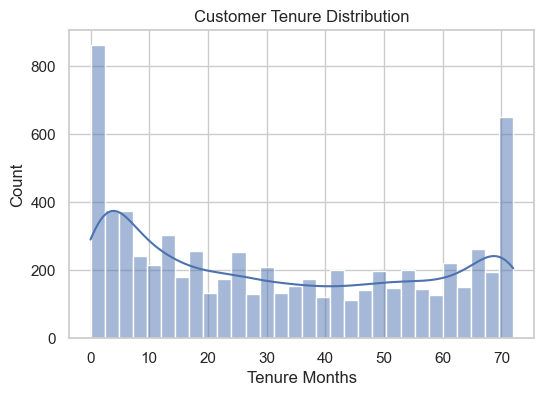

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["Tenure Months"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

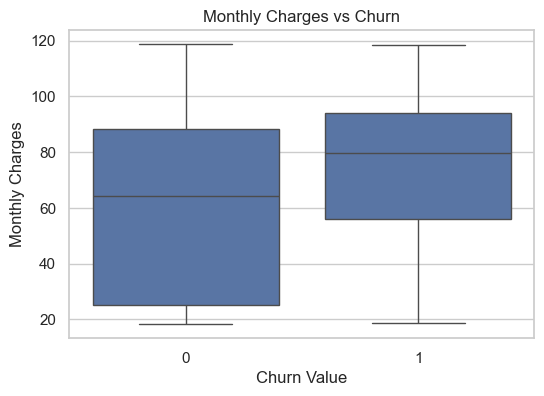

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn Value", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

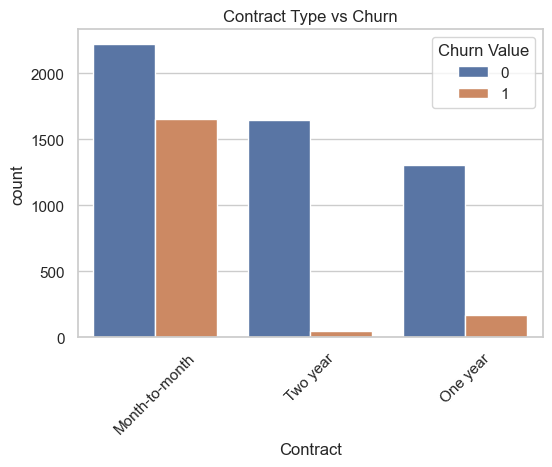

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="Churn Value", data=df)
plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()

In [13]:
# segmentation phse

In [14]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].isnull().sum()

np.int64(11)

In [15]:
df = df.dropna(subset=["Total Charges"]).copy()

In [16]:
service_cols = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]

df["ServiceCount"] = (df[service_cols] == "Yes").sum(axis=1)

In [17]:
segmentation_features = ["Tenure Months", "Monthly Charges", "Total Charges", "ServiceCount"]

seg_df = df[segmentation_features].copy()
seg_df.head()

,Tenure Months,Monthly Charges,Total Charges,ServiceCount
0,2,53.85,108.15,3
1,2,70.70,151.65,1
2,8,99.65,820.50,5
3,28,104.80,3046.05,6
4,49,103.70,5036.30,6


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_df)

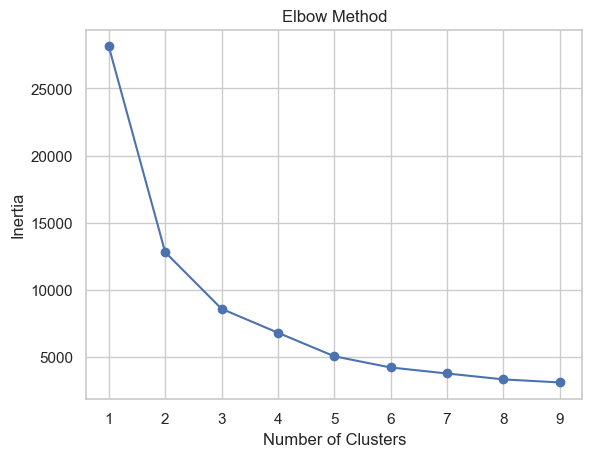

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(seg_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(seg_scaled)
    score = silhouette_score(seg_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.4670
K=3, Silhouette Score=0.4089
K=4, Silhouette Score=0.3688
K=5, Silhouette Score=0.3873
K=6, Silhouette Score=0.3723
K=7, Silhouette Score=0.3662


In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Segment"] = kmeans.fit_predict(seg_scaled)

In [22]:
df.groupby("Segment")[segmentation_features].mean()

,Tenure Months,Monthly Charges,Total Charges,ServiceCount
Segment,,,,
0,58.837825,90.671277,5321.121182,5.653901
1,26.409781,28.360519,709.339165,1.364671
2,16.072299,77.257407,1225.715088,3.322593


In [23]:
# interpreting what is found by clustering b4 we run the k means algo

In [24]:
df["Segment"].value_counts()

Segment
2    2545
1    2372
0    2115
Name: count, dtype: int64

In [25]:
df.groupby("Segment")[segmentation_features].mean()

,Tenure Months,Monthly Charges,Total Charges,ServiceCount
Segment,,,,
0,58.837825,90.671277,5321.121182,5.653901
1,26.409781,28.360519,709.339165,1.364671
2,16.072299,77.257407,1225.715088,3.322593


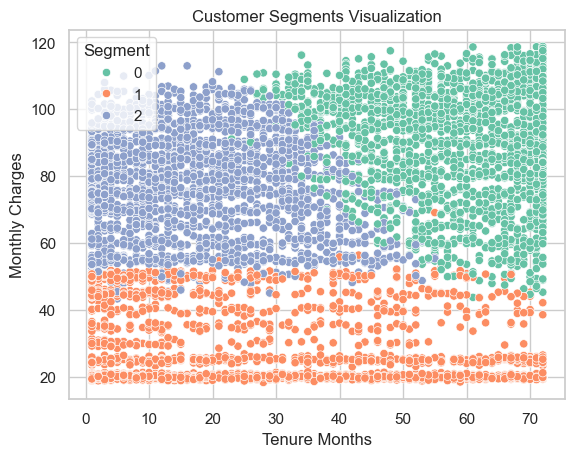

In [26]:
import seaborn as sns

sns.scatterplot(
    x="Tenure Months",
    y="Monthly Charges",
    hue="Segment",
    data=df,
    palette="Set2"
)
plt.title("Customer Segments Visualization")
plt.show()

In [27]:
df.groupby("Segment")["Churn Value"].value_counts(normalize=True)

Segment  Churn Value
0        0              0.850591
         1              0.149409
1        0              0.837268
         1              0.162732
2        0              0.541454
         1              0.458546
Name: proportion, dtype: float64

In [28]:
# phase 4- churn model

In [29]:

df.shape

(7032, 35)

In [30]:
y = df["Churn Value"]

In [31]:
y.value_counts()

Churn Value
0    5163
1    1869
Name: count, dtype: int64

In [32]:
X = df.drop(columns=[
    "CustomerID",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "CLTV",
    "Churn Value"
])

In [33]:
X = X.drop(columns=[
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
])

In [34]:
X = pd.get_dummies(X, drop_first=True)

In [35]:
X.shape

(7032, 32)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.65      0.61      0.63       374

    accuracy                           0.81      1407
   macro avg       0.76      0.75      0.75      1407
weighted avg       0.81      0.81      0.81      1407



In [40]:
confusion_matrix(y_test, y_pred)

array([[911, 122],
       [146, 228]])

In [41]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
12,Internet Service_Fiber optic,0.653626
30,Payment Method_Electronic check,0.369609
11,Multiple Lines_Yes,0.364990
10,Multiple Lines_No phone service,0.326346
23,Streaming TV_Yes,0.292172
28,Paperless Billing_Yes,0.281073
7,Partner_Yes,0.253339
25,Streaming Movies_Yes,0.251182
31,Payment Method_Mailed check,0.084539
6,Senior Citizen_Yes,0.060822


In [42]:
#Evaluation stage

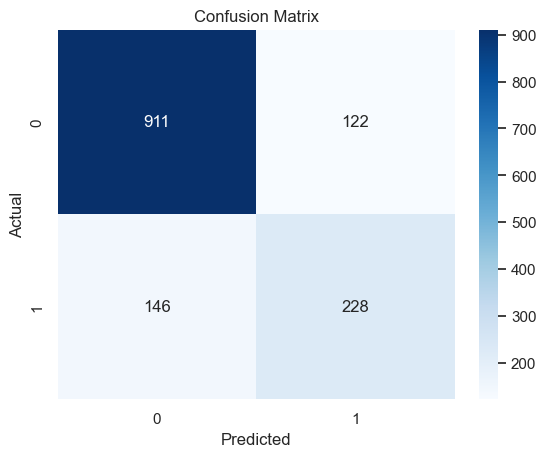

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
12,Internet Service_Fiber optic,0.653626
30,Payment Method_Electronic check,0.369609
11,Multiple Lines_Yes,0.364990
10,Multiple Lines_No phone service,0.326346
23,Streaming TV_Yes,0.292172
28,Paperless Billing_Yes,0.281073
7,Partner_Yes,0.253339
25,Streaming Movies_Yes,0.251182
31,Payment Method_Mailed check,0.084539
6,Senior Citizen_Yes,0.060822


In [45]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8428710831335966

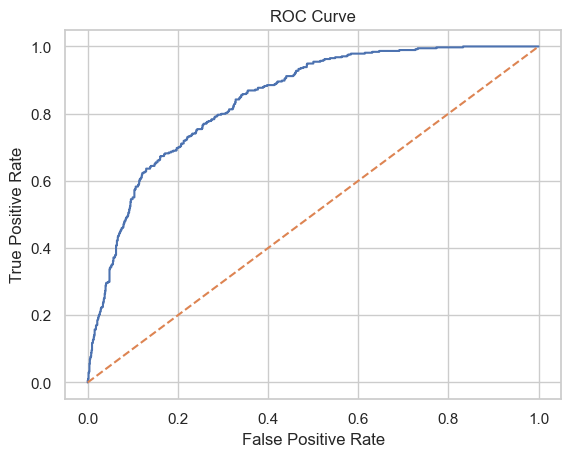

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [48]:
df["PredictedChurn"] = model.predict(X)

df.groupby("Segment")["PredictedChurn"].mean()

Segment
0    0.072340
1    0.083474
2    0.524165
Name: PredictedChurn, dtype: float64

In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.59      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.77      1407

ROC-AUC: 0.8344381403005627


In [50]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000875 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.54      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407

ROC-AUC: 0.8370187554032438


In [51]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("lgb", lgb)
    ],
    voting="soft"
)

ensemble.fit(X_train, y_train)

y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_ens))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_ens))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8366770892111135


In [52]:
import pandas as pd
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Ensemble"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb),
        accuracy_score(y_test, y_pred_ens)
    ],
    
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgb),
        roc_auc_score(y_test, y_prob_ens)
    ]
})

results.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.809524,0.842871
3,LightGBM,0.782516,0.837019
4,Ensemble,0.786070,0.836677
2,XGBoost,0.778962,0.834438
1,Random Forest,0.788913,0.830205


In [53]:
import joblib

joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [54]:
#phase 5- SHAP

In [55]:
import numpy as np

X_train_np = X_train.astype(float).values
X_test_np = X_test.astype(float).values

In [56]:
import shap

explainer = shap.Explainer(model, X_train_np)

C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
shap_values = explainer(X_test_np)

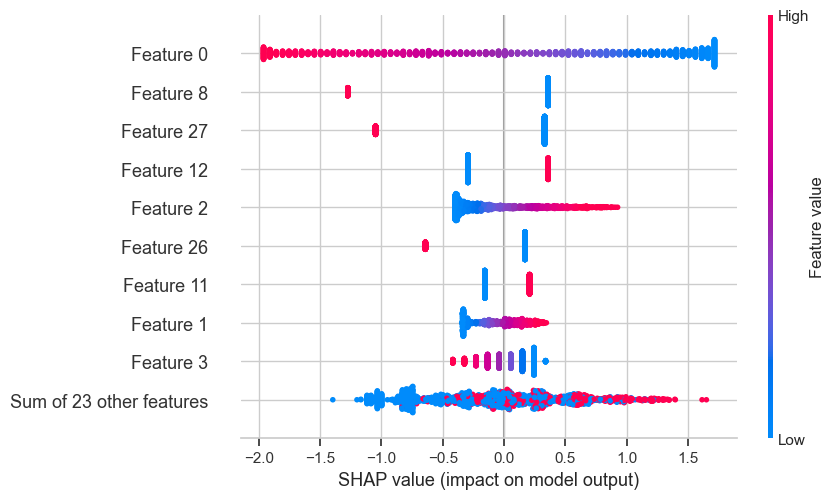

In [58]:
shap.plots.beeswarm(shap_values)

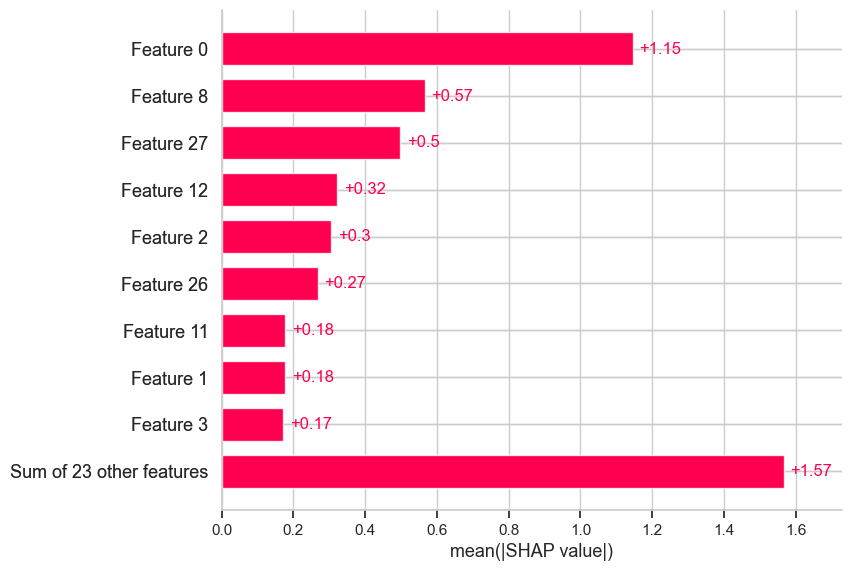

In [59]:
shap.plots.bar(shap_values)

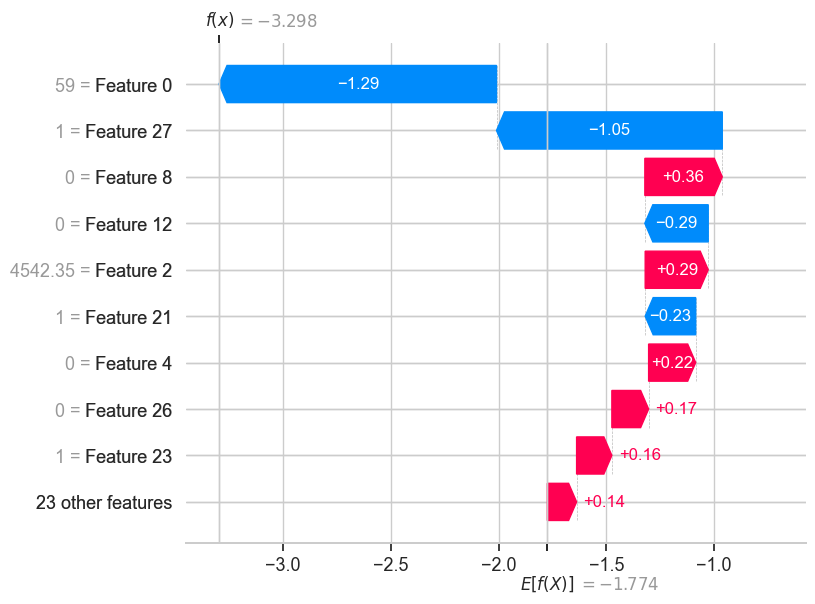

In [60]:
shap.plots.waterfall(shap_values[0])

In [61]:
#phase 6: optimizing furthur (cross validation, hyperParameter Tuning, early stopping and regularization)

In [62]:
#HyperParameterization 
import numpy as np

param_grid = {
    "model__C": np.logspace(-4, 4, 20),   # 0.0001 → 10000
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

NameError: name 'GridSearchCV' is not defined

In [ ]:
#Cross Validation
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [ ]:
#final grid search
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best Params: {'model__C': np.float64(78.47599703514607), 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.8609767023633477


C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
#RandomizedSearch
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': array([1.0000...00000000e+04]), 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.2

In [ ]:
y_prob_best = search.best_estimator_.predict_proba(X_test)[:,1]

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (baseline)",
        "Logistic Regression (tuned)"
    ],
    
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_best)
    ]
})

comparison

,Model,ROC_AUC
0,Logistic Regression (baseline),0.842871
1,Logistic Regression (tuned),0.841776


In [ ]:
print(search.best_params_)
print(search.best_score_)

{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': np.float64(78.47599703514607)}
0.8609767023633477


In [ ]:
import joblib

joblib.dump(best_model, "../src/models/churn_model.pkl")

['../src/models/churn_model.pkl']

In [ ]:
#phase 7: trying out neural networks, catboost and proper stacking techniques

In [63]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),   # VERY IMPORTANT
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=64,
        learning_rate="adaptive",
        max_iter=500,
        random_state=42
    ))
])

# Train
mlp_pipeline.fit(X_train, y_train)

# Predict probabilities
y_prob_mlp = mlp_pipeline.predict_proba(X_test)[:,1]

# Evaluate
print("MLP ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))

MLP ROC-AUC: 0.7681160733236356


In [65]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 539.2 kB/s eta 0:03:05
   ---------------------------------------- 0.5/100.2 MB 539.2 kB/s eta 0:03:05
   ---------------------------------------- 0.8/100.2 MB 560.4 kB/s eta 0:02:58
   ---------------------------------------- 0.8/100.2 MB 560.4 kB/s eta 0:02:58
   ---------------------------------------- 1.0/100.2 MB 574.6 kB/s eta 0:02:53
   ---------------------------------------- 1.0/100.2 MB 574.6 kB/s eta 0:02:53
   ---------------------------------------- 1.0/100.2 MB 574.6 kB/s eta 0:02:53
    ---

In [66]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)

y_prob_cat = cat_model.predict_proba(X_test)[:,1]

print("CatBoost ROC-AUC:", roc_auc_score(y_test, y_prob_cat))

CatBoost ROC-AUC: 0.828356740918668


In [67]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

models = {
    "lr": LogisticRegression(max_iter=5000),
    "lgbm": LGBMClassifier(n_estimators=300),
    "mlp": mlp_pipeline
}

In [69]:
from sklearn.base import clone

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros((X_train.shape[0], len(models)))
test_preds = np.zeros((X_test.shape[0], len(models)))

for i, (name, model) in enumerate(models.items()):
    print(f"Training {name}...")
    
    test_fold_preds = np.zeros((X_test.shape[0], 5))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        
        # FIX HERE
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        
        oof_preds[val_idx, i] = model_clone.predict_proba(X_val)[:,1]
        test_fold_preds[:, fold] = model_clone.predict_proba(X_test)[:,1]
    
    test_preds[:, i] = test_fold_preds.mean(axis=1)

Training lr...
Training lgbm...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1196, number of negative: 3304
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1196, number of negative: 3304
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train s

In [70]:
meta_model = LogisticRegression()

meta_model.fit(oof_preds, y_train)

# Final predictions
final_preds = meta_model.predict_proba(test_preds)[:,1]

print("Stacked ROC-AUC:", roc_auc_score(y_test, final_preds))

Stacked ROC-AUC: 0.8443231644501503


In [72]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_prob_log = log_model.predict_proba(X_test)[:,1]

In [73]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM",
        "MLP",
        "CatBoost",
        "Stacked Model"
    ],
    
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_lgb),
        roc_auc_score(y_test, y_prob_mlp),
        roc_auc_score(y_test, y_prob_cat),
        roc_auc_score(y_test, final_preds)
    ]
}).sort_values("ROC_AUC", ascending=False)

comparison

,Model,ROC_AUC
4,Stacked Model,0.844323
0,Logistic Regression,0.842736
1,LightGBM,0.837019
3,CatBoost,0.828357
2,MLP,0.768116
